In [1]:
import numpy as np
from numpy import ndarray
import scipy.integrate as spyint
import yt
from yt.frontends.ramses.field_handlers import RTFieldFileHandler

import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
from astropy.constants import c

In [2]:
def ergcm2s_to_jyhz(F_erg_cm2_s):
    # 1 erg/s/cm^2 = 1e23 Jy Hz

    return F_erg_cm2_s * 1e23

def gaussian_spectrum_from_integrated_flux_erg(
    lambda_array: ndarray,          # wavelength grid (Å)
    line_cents_array: ndarray,      # line centers (Å)
    sigma_v_kms: ndarray,           # Gaussian sigma in km/s (scalar or array)
    F_line_erg_cm2_s: ndarray       # integrated fluxes (erg/s/cm^2), array
):
    """
    Returns the combined line spectrum S(λ) in Jy.
    Gaussian profile defined in frequency domain but evaluated on λ grid.
    """

    # ---- Convert inputs to arrays ----
    lambda_array = np.asarray(lambda_array, float)        # (Nλ,)
    line_cents_array = np.asarray(line_cents_array, float)  # (Nlines,)
    sigma_v_kms = np.asarray(sigma_v_kms, float)            # scalar or (Nlines,)
    F_line_erg_cm2_s = np.asarray(F_line_erg_cm2_s, float)  # (Nlines,)

    # ---- Convert wavelength to frequency ----
    # Å → cm
    lam_cm = lambda_array * 1e-8
    lam0_cm = line_cents_array * 1e-8

    # λ → ν conversion
    nu_array = c.cgs.to_value() / lam_cm         # Hz, shape (Nλ,)
    nu0 = c.cgs.to_value()  / lam0_cm             # Hz, shape (Nlines,)

    # ---- Convert integrated flux to (Jy Hz) ----
    F_jyhz = ergcm2s_to_jyhz(F_line_erg_cm2_s)  # shape (Nlines,)

    # ---- Convert sigma_v → sigma_nu ---- # frankly don't know how this works
    sigma_nu = (nu0 / 2.99792458e5) * sigma_v_kms   # km/s to Hz

    # ---- Gaussian amplitude in Jy ----
    A_jy = F_jyhz / (sigma_nu * np.sqrt(2*np.pi))

    # ---- Broadcast Gaussian calculation ----
    # nu_array: (Nλ,) → (1, Nλ)
    # nu0:      (Nlines,) → (Nlines, 1)
    nu_diff = nu_array[None, :] - nu0[:, None]

    S_each = A_jy[:, None] * np.exp(-0.5 * (nu_diff / sigma_nu[:, None])**2)

    # ---- Sum over all lines ----
    S_total = np.sum(S_each, axis=0)

    return S_total

[6562.8  1304.86 6300.3  3728.8  3726.1  1660.81 1666.15 4363.21 4958.91
 5006.84 1640.41 1335.66 1906.68 1908.73 1549.   2795.53 2802.71 3868.76
 3967.47 1238.82 1242.8  1486.5  1749.67 6716.44 6730.82]
[1.11038397e+33 1.61987041e+23 3.08478008e+25 1.10030553e+26
 7.36523736e+25 1.42284162e+20 4.16672132e+20 2.23057721e+20
 3.42479658e+21 1.02181761e+22 1.94937115e+26 9.49045329e+23
 7.13504646e+23 4.65396763e+23 0.00000000e+00 1.32946960e+26
 6.71589080e+25 3.00994268e+21 9.13560277e+20 0.00000000e+00
 0.00000000e+00 0.00000000e+00 1.90161008e+21 1.01859885e+26
 7.02687477e+25]


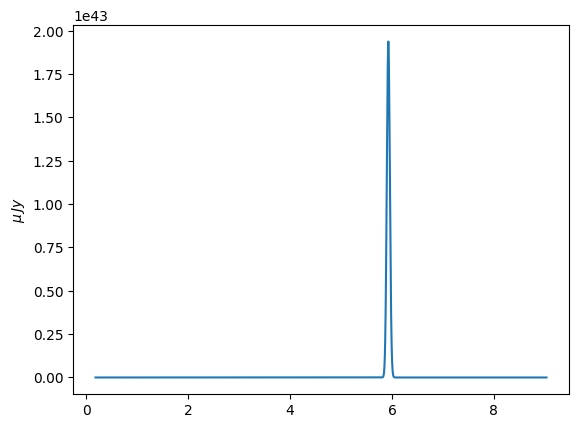

In [ ]:
wavelengths = np.array([
    6562.80, 1304.86, 6300.30, 3728.80, 3726.10,
    1660.81, 1666.15, 4363.21, 4958.91, 5006.84,
    1640.41, 1335.66, 1906.68, 1908.73, 1549.00,
    2795.53, 2802.71, 3868.76, 3967.47, 1238.82,
    1242.80, 1486.50, 1749.67, 6716.44, 6730.82
])

F_values = np.array([
    1.11038397e33, 1.61987041e23, 3.08478008e25, 1.10030553e26,
    7.36523736e25, 1.42284162e20, 4.16672132e20, 2.23057721e20,
    3.42479658e21, 1.02181761e22, 1.94937115e26, 9.49045329e23,
    7.13504646e23, 4.65396763e23, 0.0, 1.3294696e26,
    6.7158908e25, 3.00994268e21, 9.13560277e20, 0.0,
    0.0, 0.0, 1.90161008e21, 1.01859885e26, 7.02687477e25
])

z_test = 8.033

testx = np.linspace(200,10000,40000) * u.Angstrom
out = gaussian_spectrum_from_integrated_flux_erg(testx, wavelengths, 150, F_values)
testx_mic = (testx * (1+z_test)).to(u.micron)
plt.plot(testx_mic, out)
# plt.xlim(0.5,6)
# plt.ylim(-0.000001,0.00001)
plt.ylabel(r"$\mu \, Jy$")
print(f"{wavelengths}\n{F_values}")